# 14 — Dynamic Programming: Policy Iteration
*From arbitrary behavior to optimal policies via alternating evaluation and improvement.*

**What you’ll learn**

- How policy evaluation and policy improvement combine into policy iteration.  
- How to implement policy iteration on the classic 4×4 Gridworld.  
- How to visualize value functions and policies (arrows) on a grid.  
- Why policy iteration converges to the optimal policy in finite MDPs.

> This notebook assumes you’ve seen:  
> `11_markov_decision_processes.ipynb`, `12_bellman_equations.ipynb`, and `13_dp_policy_evaluation.ipynb`.

## 1. Theory — Policy Evaluation + Policy Improvement

We work with a finite discounted MDP with states $ \mathcal{S} $, actions $ \mathcal{A} $, transition dynamics $ p(s', r \mid s, a) $, and discount $ \gamma \in [0,1) $.

A policy $ \pi(a \mid s) $ defines a distribution over actions for each state.


### 1.1 Policy Evaluation (Reminder)

Given a policy $ \pi $, the state-value function $ v_\pi $ satisfies the Bellman expectation equation:

$$
v_\pi(s) = \mathbb{E}_\pi \big[ R_{t+1} + \gamma v_\pi(S_{t+1}) \mid S_t = s \big]
= \sum_a \pi(a\mid s) \sum_{s',r} p(s',r\mid s,a)\,\big[r + \gamma v_\pi(s')\big].
$$

In matrix form (for Markov reward processes / fixed policy):

$$
v_\pi = r^\pi + \gamma P^\pi v_\pi
\quad \Longrightarrow \quad
v_\pi = (I - \gamma P^\pi)^{-1} r^\pi.
$$

We typically solve this iteratively using dynamic programming (DP):

$$
v_{k+1}(s) \leftarrow \sum_a \pi(a\mid s) \sum_{s'} P(s' \mid s, a)
\big[R(s,a,s') + \gamma v_k(s')\big].
$$


### 1.2 Policy Improvement

If we have $ v_\pi $, we can define the state–action value:

$$
q_\pi(s,a) = \sum_{s',r} p(s',r\mid s,a)\,\big[r + \gamma v_\pi(s')\big].
$$

A greedy policy w.r.t. $ v_\pi $ is:

$$
\pi'(s) = \arg\max_a q_\pi(s,a).
$$

The Policy Improvement Theorem says:
> If for all $s$, $ q_\pi(s, \pi'(s)) \ge v_\pi(s) $, then $ v_{\pi'}(s) \ge v_\pi(s) $ for all $s$, and strictly better in some state if inequality is strict somewhere.

So greedy improvement never makes the policy worse.


### 1.3 Policy Iteration Algorithm

Policy iteration alternates:

1. **Policy Evaluation:** Find $ v_\pi $ for current policy $ \pi $.
2. **Policy Improvement:** Greedify w.r.t. $ v_\pi $ to obtain $ \pi' $.

Pseudocode (deterministic policies):

```text
Initialize π(s) arbitrarily for all s
loop:
    # Policy Evaluation
    compute v_π (e.g., iterative DP until convergence)

    # Policy Improvement
    policy_stable = True
    for each state s:
        old_action = π(s)
        π(s) = argmax_a q_π(s,a)
        if π(s) != old_action:
            policy_stable = False

    if policy_stable:
        return π, v_π   # π is optimal
```

For finite discounted MDPs, this converges to an optimal policy $ \pi^* $ in a finite number of iterations.

## 2. Environment Setup — 4×4 Gridworld (Sutton-style)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

# We use a 4x4 Gridworld:
# - States: 0..15 laid out row-wise
# - Terminals: 0 (top-left) and 15 (bottom-right)
# - Actions: 0=up, 1=right, 2=down, 3=left
# - Reward: -1 per step until reaching a terminal
# - Discount: gamma

GRID_H = 4
GRID_W = 4
N_STATES = GRID_H * GRID_W
ACTIONS = np.array([0, 1, 2, 3])  # up, right, down, left
N_ACTIONS = len(ACTIONS)

TERMINAL_STATES = {0, N_STATES - 1}


def state_to_coord(s):
    return divmod(s, GRID_W)  # (row, col)


def coord_to_state(i, j):
    return i * GRID_W + j


def step_grid(s, a):
    """Deterministic transition for the grid. Returns (s', reward, done)."""
    if s in TERMINAL_STATES:
        return s, 0.0, True

    i, j = state_to_coord(s)
    if a == 0:      # up
        i = max(i - 1, 0)
    elif a == 1:    # right
        j = min(j + 1, GRID_W - 1)
    elif a == 2:    # down
        i = min(i + 1, GRID_H - 1)
    elif a == 3:    # left
        j = max(j - 1, 0)

    s_next = coord_to_state(i, j)
    reward = -1.0
    done = s_next in TERMINAL_STATES
    return s_next, reward, done


def build_tabular_mdp(gamma=1.0):
    """
    Build P and R for the gridworld MDP.

    P[s, a, s'] = probability of transitioning from s to s' under action a.
    R[s, a]     = expected immediate reward for (s,a).
    """
    P = np.zeros((N_STATES, N_ACTIONS, N_STATES), dtype=float)
    R = np.zeros((N_STATES, N_ACTIONS), dtype=float)

    for s in range(N_STATES):
        for ai, a in enumerate(ACTIONS):
            s_next, r, done = step_grid(s, a)
            P[s, ai, s_next] = 1.0
            R[s, ai] = r

    return P, R, gamma


P, R, gamma = build_tabular_mdp(gamma=1.0)

print("P shape:", P.shape)
print("R shape:", R.shape)
print("Terminal states:", TERMINAL_STATES)

P shape: (16, 4, 16)
R shape: (16, 4)
Terminal states: {0, 15}


## 3. Policy Evaluation Helper (Deterministic Policies)

We’ll reuse iterative policy evaluation, but specialized for deterministic policies:

- Policy is represented as an integer array `policy[s] ∈ {0,1,2,3}`.  
- For each non-terminal state $s$, we apply its chosen action, compute its 1-step return, and iterate until convergence:

$$
v_{k+1}(s) \leftarrow R(s,\pi(s)) + \gamma \sum_{s'} P(s' \mid s,\pi(s)) v_k(s').
$$

We stop when the max change across states drops below a threshold `theta`.

In [2]:
def evaluate_policy(P, R, gamma, policy, theta=1e-4, max_iters=10_000, verbose=False):
    """
    Iterative policy evaluation for a deterministic policy on the gridworld.

    Args:
        P: (S, A, S) transition probabilities
        R: (S, A) rewards
        gamma: discount factor
        policy: (S,) int array of actions
        theta: convergence tolerance
        max_iters: safety cap
    Returns:
        v: (S,) value function for this policy
        num_iters: number of sweeps performed
    """
    S, A, _ = P.shape
    v = np.zeros(S, dtype=float)

    for it in range(max_iters):
        delta = 0.0
        v_new = v.copy()

        for s in range(S):
            if s in TERMINAL_STATES:
                continue

            a = policy[s]
            # One-step expectation: v(s) = R(s,a) + gamma * sum_s' P * v(s')
            v_new[s] = R[s, a] + gamma * np.dot(P[s, a], v)

            delta = max(delta, abs(v_new[s] - v[s]))

        v = v_new

        if verbose and (it % 50 == 0):
            print(f"[eval] iter={it}, delta={delta:.6f}")

        if delta < theta:
            return v, it + 1

    return v, max_iters

## 4. Policy Improvement & Policy Iteration

### 4.1 Greedy Policy Improvement

Given a value function $v$, we compute for each state $s$ and each action $a$:

$$
q(s,a) = R(s,a) + \gamma \sum_{s'} P(s' \mid s,a) v(s').
$$

We then set the improved policy as:

$$
\pi'(s) = \arg\max_a q(s,a).
$$

If the improved policy matches the old policy for all states, we’re done: the policy is optimal.


### 4.2 Policy Iteration Loop

We implement full policy iteration:

1. Initialize a random / uniform policy.  
2. Evaluate it with `evaluate_policy`.  
3. Improve greedily; check if anything changed.  
4. Repeat until stable.

In [3]:
def greedy_policy_improvement(P, R, gamma, v, policy_old):
    """
    Greedy policy improvement w.r.t. value function v.

    Returns:
        new_policy: improved deterministic policy
        policy_stable: True if no change vs policy_old
    """
    S, A, _ = P.shape
    new_policy = policy_old.copy()
    policy_stable = True

    for s in range(S):
        if s in TERMINAL_STATES:
            continue

        # Compute q(s,a) for all actions
        q_sa = np.zeros(A, dtype=float)
        for a in range(A):
            q_sa[a] = R[s, a] + gamma * np.dot(P[s, a], v)

        best_a = int(np.argmax(q_sa))
        if best_a != policy_old[s]:
            policy_stable = False
        new_policy[s] = best_a

    return new_policy, policy_stable


def policy_iteration(P, R, gamma, theta=1e-4, max_eval_iters=10_000, verbose=True):
    """
    Full policy iteration on the 4x4 Gridworld.

    Returns:
        policy: optimal deterministic policy
        v: corresponding value function
        history: list of (v_snapshot, policy_snapshot) for each outer iteration
    """
    S, A, _ = P.shape

    # Start from a random policy on non-terminal states
    rng = np.random.default_rng(0)
    policy = rng.integers(low=0, high=A, size=S, dtype=int)
    for s in TERMINAL_STATES:
        policy[s] = 0  # arbitrary, unused in terminals

    history = []

    while True:
        if verbose:
            print("=== Policy Evaluation ===")
        v, eval_iters = evaluate_policy(P, R, gamma, policy,
                                        theta=theta, max_iters=max_eval_iters)
        if verbose:
            print(f"Policy evaluation converged in {eval_iters} sweeps.")

        history.append((v.copy(), policy.copy()))

        if verbose:
            print("=== Policy Improvement ===")
        new_policy, stable = greedy_policy_improvement(P, R, gamma, v, policy)

        if verbose:
            changed = (new_policy != policy).sum()
            print(f"Policy changed in {changed} states.")
            print(f"Policy stable? {stable}")

        policy = new_policy

        if stable:
            if verbose:
                print("\nPolicy iteration converged: found an optimal policy.")
            break

    return policy, v, history


opt_policy, opt_v, hist = policy_iteration(P, R, gamma, theta=1e-4, verbose=True)
print("\nOptimal value function v*:\n", opt_v.reshape(GRID_H, GRID_W))
print("\nOptimal policy (as action indices):\n", opt_policy.reshape(GRID_H, GRID_W))

=== Policy Evaluation ===
Policy evaluation converged in 10000 sweeps.
=== Policy Improvement ===
Policy changed in 10 states.
Policy stable? False
=== Policy Evaluation ===
Policy evaluation converged in 10000 sweeps.
=== Policy Improvement ===
Policy changed in 5 states.
Policy stable? False
=== Policy Evaluation ===
Policy evaluation converged in 10000 sweeps.
=== Policy Improvement ===
Policy changed in 2 states.
Policy stable? False
=== Policy Evaluation ===
Policy evaluation converged in 4 sweeps.
=== Policy Improvement ===
Policy changed in 0 states.
Policy stable? True

Policy iteration converged: found an optimal policy.

Optimal value function v*:
 [[ 0. -1. -2. -3.]
 [-1. -2. -3. -2.]
 [-2. -3. -2. -1.]
 [-3. -2. -1.  0.]]

Optimal policy (as action indices):
 [[0 3 3 2]
 [0 0 0 2]
 [0 0 1 2]
 [0 1 1 0]]


## 5. Visualizing Policies & Values on the Grid

Let’s visualize:

- The value function as a heatmap over the 4×4 grid.  
- The policy as arrows in each non-terminal state.

Optimal policy (arrows):
■ ← ← ↓
↑ ↑ ↑ ↓
↑ ↑ → ↓
↑ → → ■


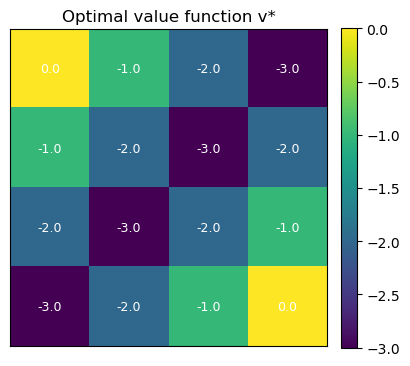

In [4]:
# Helper: action → arrow
ACTION_SYMBOLS = {
    0: "↑",
    1: "→",
    2: "↓",
    3: "←",
}


def print_policy(policy, terminal_states=TERMINAL_STATES, H=GRID_H, W=GRID_W):
    """Pretty-print policy as arrows on a H×W grid."""
    grid = []
    for i in range(H):
        row_syms = []
        for j in range(W):
            s = coord_to_state(i, j)
            if s in terminal_states:
                row_syms.append("■")  # terminal
            else:
                a = int(policy[s])
                row_syms.append(ACTION_SYMBOLS[a])
        grid.append(" ".join(row_syms))
    print("\n".join(grid))


def plot_value_heatmap(v, title="Value function", H=GRID_H, W=GRID_W):
    grid_v = v.reshape(H, W)
    plt.figure(figsize=(4.2, 3.8))
    im = plt.imshow(grid_v, cmap="viridis", origin="upper")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    for i in range(H):
        for j in range(W):
            plt.text(j, i, f"{grid_v[i,j]:.1f}",
                     ha="center", va="center", color="white", fontsize=9)
    plt.title(title)
    plt.xticks([]); plt.yticks([])
    plt.tight_layout()
    plt.show()


print("Optimal policy (arrows):")
print_policy(opt_policy)

plot_value_heatmap(opt_v, title="Optimal value function v*")

### Output Analysis

- **Optimal value function $v^*$:**  
  Values represent expected cumulative return under the optimal policy. Terminal states have value 0; values decrease by ~1 per step away due to the step cost.

- **Optimal policy:**  
  Arrows point toward the nearest terminal, choosing shortest paths and avoiding extra steps.

- **Sanity check:**  
  Symmetry in values and actions matches the grid and reward structure, confirming correct convergence of policy iteration.

## 6. Comparing to “Partial” Policy Iteration

One practical variant is to not fully solve the policy evaluation step each time, but do:

- A fixed number of evaluation sweeps (e.g., 5 or 10 Bellman updates), then
- A greedy improvement step again.

This is sometimes called modified policy iteration and interpolates between:

- Value iteration (1 sweep per improvement), and  
- Classical policy iteration (fully evaluate each time).

We’ll do a small experiment with *partial evaluation* to show it still converges.

Modified PI — optimal policy (arrows):
■ ← ← ↓
↑ ↑ ↑ ↓
↑ ↑ → ↓
↑ → → ■


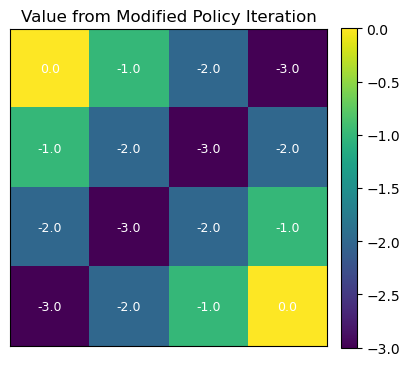

In [6]:
def partial_policy_iteration(P, R, gamma, theta=1e-4,
                             max_eval_sweeps=5, max_outer_iters=100, verbose=True):
    """
    Modified policy iteration:
    - Do at most max_eval_sweeps evaluation sweeps per outer loop.
    - Then greedy policy improvement.
    """
    S, A, _ = P.shape
    rng = np.random.default_rng(1)
    policy = rng.integers(low=0, high=A, size=S, dtype=int)
    for s in TERMINAL_STATES:
        policy[s] = 0

    v = np.zeros(S, dtype=float)
    outer_hist = []

    for outer in range(max_outer_iters):
        if verbose:
            print(f"\n=== Outer iter {outer} ===")

        # Partial evaluation
        for sweep in range(max_eval_sweeps):
            delta = 0.0
            v_new = v.copy()
            for s in range(S):
                if s in TERMINAL_STATES:
                    continue
                a = policy[s]
                v_new[s] = R[s, a] + gamma * np.dot(P[s, a], v)
                delta = max(delta, abs(v_new[s] - v[s]))
            v = v_new

            if delta < theta:
                if verbose:
                    print(f"  Evaluation converged early at sweep={sweep}, delta={delta:.6g}")
                break

        outer_hist.append((v.copy(), policy.copy()))

        # Improvement
        new_policy, stable = greedy_policy_improvement(P, R, gamma, v, policy)
        changes = (new_policy != policy).sum()
        if verbose:
            print(f"  Policy changes: {changes}, stable? {stable}")
        policy = new_policy

        if stable:
            if verbose:
                print("Modified policy iteration converged.")
            break

    return policy, v, outer_hist


mpi_policy, mpi_v, mpi_hist = partial_policy_iteration(
    P, R, gamma, theta=1e-4, max_eval_sweeps=5, verbose=False
)

print("Modified PI — optimal policy (arrows):")
print_policy(mpi_policy)
plot_value_heatmap(mpi_v, title="Value from Modified Policy Iteration")

## Key Takeaways

- Policy evaluation computes $v_\pi$ for a fixed policy by solving the Bellman expectation equation.  
- Policy improvement greedifies w.r.t. $v_\pi$, producing a better (or equal) policy.  
- Policy iteration alternates evaluation and improvement and converges to an optimal policy in finite discounted MDPs.  
- Implementation is straightforward for tabular MDPs: you need $P$, $R$, and a deterministic policy array.  
- Variants like modified policy iteration trade off evaluation accuracy vs. speed and connect policy iteration to value iteration.

**Next:** `15_dp_value_iteration.ipynb` → directly iterating the optimal Bellman operator $v_{k+1} = \max_a T^a v_k$ without an explicit policy evaluation step.